# 01. Difference-in-Differences

Difference-in-differences (DiD) is the workhorse design for policy changes, product rollouts, pricing changes, marketplace rules, support operations, and other interventions that happen in one group at one time but not in another group.

The basic move is simple: compare how outcomes changed in the treated group before and after the intervention, then subtract how outcomes changed in a comparison group over the same calendar period. The difficult part is not the arithmetic. The difficult part is defending the counterfactual trend.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain the difference-in-differences estimand in potential-outcomes language.
- Compute a 2x2 DiD estimate by hand from group-period means.
- Estimate DiD with a regression and with unit and time fixed effects.
- Explain the parallel-trends and common-shocks assumptions.
- Diagnose pre-treatment trends with plots, slope checks, and placebo timing tests.
- Understand why standard errors usually need to account for repeated observations within units.
- Recognize what goes wrong when a treated group gets a simultaneous shock unrelated to the intervention.
- Translate a DiD estimate into an industry-facing decision readout.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def did_from_group_means(frame, outcome="revenue"):
    """Compute the manual 2x2 difference-in-differences contrast from group-period means.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        outcome: Outcome variable name or vector being analyzed.

    Returns:
        tuple: Group-period mean table and DiD estimate.
    """
    means = (
        frame.groupby(["treated_region", "post"], observed=True)[outcome]
        .mean()
        .unstack()
        .rename(index={0: "Comparison", 1: "Treated"}, columns={0: "Pre", 1: "Post"})
    )
    means["Change"] = means["Post"] - means["Pre"]
    did = means.loc["Treated", "Change"] - means.loc["Comparison", "Change"]
    return means, did


def extract_parameter(model, parameter):
    """Extract one model parameter with its uncertainty and p-value.

    Args:
        model: Fitted model object whose parameters or predictions are being used.
        parameter: Model parameter name to extract from a fitted object.

    Returns:
        pandas.Series: Estimate, standard error, interval, and p-value for one parameter.
    """
    ci_low, ci_high = model.conf_int().loc[parameter]
    return pd.Series(
        {
            "estimate": model.params[parameter],
            "std_error": model.bse[parameter],
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": model.pvalues[parameter],
        }
    )


def plot_coefficient_table(table, title, reference=None, xlabel="Estimate"):
    """Plot model estimates and confidence intervals for DiD specifications.

    Args:
        table: Summary table containing estimates, intervals, or diagnostics.
        title: Title shown on the resulting figure.
        reference: Reference value or omitted event time used for interpretation.
        xlabel: X-axis label for the resulting figure.

    Returns:
        tuple: Matplotlib figure and axes for the diagnostic or readout plot.
    """
    ordered = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=(8, 0.55 * len(ordered) + 1.6))
    y = np.arange(len(ordered))
    ax.errorbar(
        ordered["estimate"],
        y,
        xerr=[ordered["estimate"] - ordered["ci_low"], ordered["ci_high"] - ordered["estimate"]],
        fmt="o",
        color="#2563eb",
        ecolor="#93c5fd",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
    if reference is not None:
        ax.axvline(reference, color="#16a34a", linewidth=2, linestyle=":", label="True ATT")
        ax.legend(frameon=False)
    ax.set_yticks(y)
    ax.set_yticklabels(ordered.index)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    sns.despine(ax=ax, left=True)
    plt.tight_layout()
    return fig, ax


def plot_group_trends(frame, outcome="revenue", title="Group trends"):
    """Plot treated and comparison group trends around a rollout.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        outcome: Outcome variable name or vector being analyzed.
        title: Title shown on the resulting figure.

    Returns:
        tuple: Matplotlib figure and axes for group trend diagnostics.
    """
    trend = (
        frame.groupby(["treated_region", "month"], observed=True)[outcome]
        .mean()
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.lineplot(
        data=trend,
        x="month",
        y=outcome,
        hue="treated_region",
        marker="o",
        palette={0: "#64748b", 1: "#2563eb"},
        ax=ax,
    )
    ax.axvline(-0.5, color="#111827", linestyle="--", linewidth=1)
    ax.text(-0.45, trend[outcome].max(), "rollout", va="top", ha="left", fontsize=10)
    ax.set_title(title)
    ax.set_xlabel("Month relative to rollout")
    ax.set_ylabel("Average monthly revenue per store")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=["Comparison", "Treated"], title="Region", frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax

## 1. Why Quasi-Experiments Need Their Own Tools

Randomized experiments create exchangeability by design. Observational adjustment tries to recreate exchangeability by conditioning on measured covariates. Quasi-experiments use a different source of credibility: a policy, threshold, rollout, timing rule, capacity constraint, legal change, or operational shock that creates variation resembling an experiment.

DiD is useful when an intervention has a clear before/after date and a comparison group is exposed to the same calendar environment but not the intervention. Card and Krueger's minimum-wage study is a famous early example: New Jersey changed its minimum wage, Pennsylvania served as a comparison group, and the design compared employment changes across those groups over time (Card & Krueger, 1993).

In industry, the same structure appears constantly:

- One region gets a support-staffing policy and another region does not.
- A platform rule changes in one marketplace but not another.
- A pricing algorithm is deployed to a subset of business units after legal approval.
- A product feature launches in one country before another because of localization.
- A supply-chain intervention affects treated warehouses while comparable warehouses continue operating as before.

The design asks: did the treated group change more after the rollout than the comparison group changed during the same period?


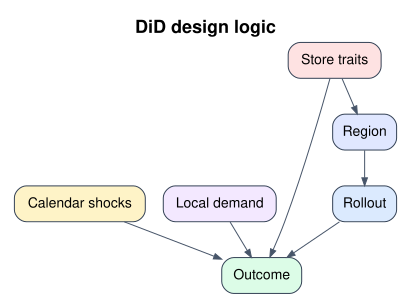

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
make_dag(
    edges=[
        ("Region", "Rollout"),
        ("Rollout", "Outcome"),
        ("Store traits", "Outcome"),
        ("Calendar shocks", "Outcome"),
        ("Store traits", "Region"),
        ("Local demand", "Outcome"),
    ],
    title="DiD design logic",
    node_colors={
        "Rollout": "#dbeafe",
        "Outcome": "#dcfce7",
        "Calendar shocks": "#fef3c7",
        "Store traits": "#fee2e2",
        "Region": "#e0e7ff",
        "Local demand": "#f3e8ff",
    },
    rankdir="TB",
)

The graph shows the heart of the design. Treated and comparison units can have different baseline levels because store traits and region assignment are not randomized. DiD removes stable level differences by differencing within group. It also removes common calendar shocks by comparing treated and comparison units in the same months.

What DiD cannot remove is a shock that hits the treated group exactly when the intervention starts and would have changed the treated group's outcome even without the intervention. That is the threat we will return to throughout this notebook.


## 2. The 2x2 Estimand

Start with the simplest setting: two groups and two periods.

Let:

- $D_i = 1$ if unit $i$ is in the treated group.
- $Post_t = 1$ in the post-intervention period.
- $Y_{it}(1)$ be the outcome if treated.
- $Y_{it}(0)$ be the outcome if not treated.

The target is usually the average treatment effect on the treated in the post period:

$$
ATT = E[Y_{i,post}(1) - Y_{i,post}(0) \mid D_i = 1]
$$

We observe $Y_{i,post}(1)$ for treated units after rollout. We do not observe $Y_{i,post}(0)$ for those same treated units. DiD imputes that missing counterfactual by using the comparison group's change:

$$
\widehat{ATT}_{DiD} =
\left(\bar{Y}_{T,post} - \bar{Y}_{T,pre}\right)
-
\left(\bar{Y}_{C,post} - \bar{Y}_{C,pre}\right)
$$

The identifying assumption is parallel trends:

$$
E[Y_{post}(0) - Y_{pre}(0) \mid D = 1]
=
E[Y_{post}(0) - Y_{pre}(0) \mid D = 0]
$$

This does not say treated and comparison groups have the same outcome level. It says their untreated changes would have been the same. Ryan (2018) emphasizes that DiD relies on both parallel trends and common shocks: the comparison group must represent how the treated group would have moved absent treatment.


## 3. Running Example: A Regional Support Rollout

Suppose a retailer launches a new proactive support program in one region. The program helps stores identify customers at risk of churn and schedule outreach before renewal dates. Leadership did not randomize the rollout; the treated region was selected because it had slightly larger stores and higher baseline loyalty-program adoption.

That creates a problem for a simple post-period treated-control comparison. Treated stores started in a different place. DiD can still be credible if, absent the support program, treated and comparison stores would have followed similar revenue trends.


**Dataset and experiment setup.** The simulated panel represents retail stores observed monthly before and after a regional support rollout. Stores belong to treated or comparison regions, and the outcome is monthly revenue per store. Treated stores differ in baseline level, which is realistic and acceptable for DiD if the untreated trends would have moved in parallel. The simulation includes store-level differences, month shocks, demand variation, and a known post-rollout treatment effect. Later sections deliberately add shocks and nonparallel trends so the notebook can show when the same estimator stops being credible.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_retail_did(
    n_stores=320,
    months=range(-6, 6),
    seed=4041,
    treatment_effect=6.0,
    differential_trend=0.0,
    treated_post_shock=0.0,
):
    """
    Generate a retail panel for difference-in-differences demonstrations.
    
    Idea:
        The simulation controls treatment timing, post-period effects, and trend violations so parallel-trend diagnostics can be interpreted against known truth.
    
    Args:
        n_stores: Number of stores included in the simulated panel.
        months: Sequence of monthly time periods in the panel simulation.
        seed: Random seed for reproducible simulation or bootstrap draws.
        treatment_effect: True treatment effect embedded in the simulation.
        differential_trend: Extra trend assigned to treated units to create or remove a parallel-trends violation.
        treated_post_shock: Additional post-period shock applied to treated stores beyond the causal effect.
    
    Returns:
        pandas.DataFrame: Store-month panel with treatment timing, outcome, covariates, and post-period indicators.
    """
    rng = np.random.default_rng(seed)
    stores = pd.DataFrame({"store_id": np.arange(n_stores)})

    stores["treated_region"] = rng.binomial(1, 0.42, n_stores)
    stores["store_size"] = rng.lognormal(mean=3.3 + 0.08 * stores["treated_region"], sigma=0.35, size=n_stores)
    stores["baseline_loyalty"] = rng.normal(0.15 + 0.35 * stores["treated_region"], 0.75, n_stores)
    stores["competition"] = rng.normal(0.0 - 0.15 * stores["treated_region"], 1.0, n_stores)

    stores["unit_fe"] = (
        62
        + 0.22 * stores["store_size"]
        + 3.2 * stores["baseline_loyalty"]
        - 1.7 * stores["competition"]
        + 3.5 * stores["treated_region"]
        + rng.normal(0, 4.5, n_stores)
    )

    rows = []
    month_values = np.array(list(months))
    for _, store in stores.iterrows():
        eps_prev = rng.normal(0, 2.0)
        store_slope = rng.normal(0, 0.08)
        for month in month_values:
            post = int(month >= 0)
            common_time = 0.55 * month + 1.8 * np.sin((month + 6) / 2.3)
            demand_index = 0.4 * store["baseline_loyalty"] + 0.25 * common_time + rng.normal(0, 0.9)
            eps = 0.55 * eps_prev + rng.normal(0, 2.2)
            eps_prev = eps

            untreated_trend = (0.18 + store_slope + differential_trend * store["treated_region"]) * month
            effect = treatment_effect * store["treated_region"] * post
            policy_confounded_shock = treated_post_shock * store["treated_region"] * post

            untreated_revenue = (
                store["unit_fe"]
                + common_time
                + untreated_trend
                + 1.6 * demand_index
                + policy_confounded_shock
                + eps
            )
            revenue = untreated_revenue + effect

            rows.append(
                {
                    "store_id": int(store["store_id"]),
                    "treated_region": int(store["treated_region"]),
                    "month": int(month),
                    "post": post,
                    "did": int(store["treated_region"] * post),
                    "store_size": store["store_size"],
                    "baseline_loyalty": store["baseline_loyalty"],
                    "competition": store["competition"],
                    "demand_index": demand_index,
                    "revenue": revenue,
                    "untreated_revenue": untreated_revenue,
                    "true_treatment_effect": effect,
                }
            )

    return pd.DataFrame(rows)


df = simulate_retail_did()
true_att = df.loc[df["did"] == 1, "true_treatment_effect"].mean()

summary = pd.Series(
    {
        "stores": df["store_id"].nunique(),
        "months": df["month"].nunique(),
        "rows": len(df),
        "treated_store_share": df.drop_duplicates("store_id")["treated_region"].mean(),
        "true_ATT_in_post_period": true_att,
    }
).to_frame("value")
smart_display(summary)

,value
stores,320.000
months,12.000
rows,3840.000
treated_store_share,0.359
true_ATT_in_post_period,6.000


The treated stores are not randomized. They differ in baseline store size, loyalty adoption, and competitive conditions. In the simulation, however, the untreated trends are parallel on average. That gives us a clean setting for learning the mechanics before we deliberately break the assumptions.


In [5]:
# Assemble the Running Example: A Regional Support Rollout summary table used for interpretation.
baseline_table = (
    df[df["month"] < 0]
    .groupby("treated_region", observed=True)
    .agg(
        stores=("store_id", "nunique"),
        avg_revenue=("revenue", "mean"),
        avg_store_size=("store_size", "mean"),
        avg_loyalty=("baseline_loyalty", "mean"),
        avg_competition=("competition", "mean"),
    )
    .rename(index={0: "Comparison", 1: "Treated"})
)
smart_display(baseline_table)


,stores,avg_revenue,avg_store_size,avg_loyalty,avg_competition
treated_region,,,,,
Comparison,205,67.125,29.079,0.170,0.031
Treated,115,72.845,30.281,0.576,-0.023


The treated region has higher pre-period revenue. DiD was built for exactly this kind of stable level difference. The question is whether the untreated change would have been similar.


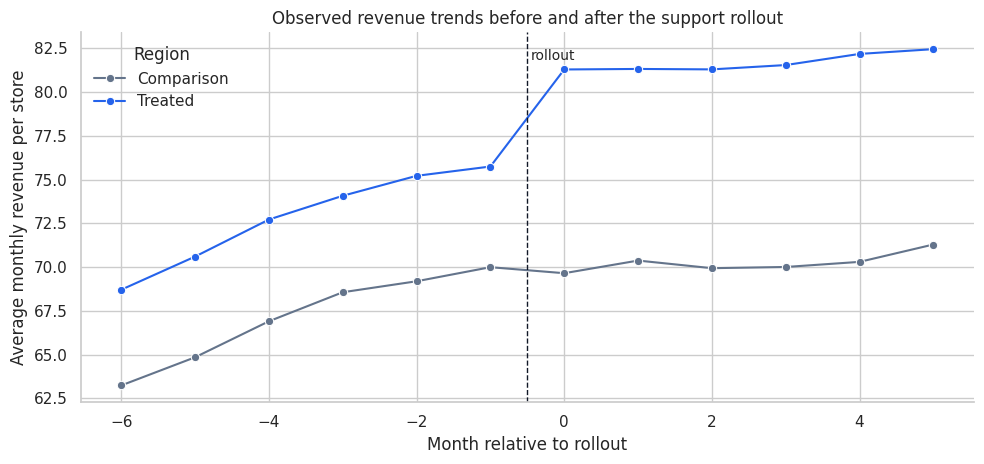

In [6]:
plot_group_trends(df, title="Observed revenue trends before and after the support rollout");


The vertical line marks the rollout. Pre-period levels differ, but the slopes are similar. After the rollout, the treated region rises more sharply. DiD attributes the extra post-period change to the intervention if the parallel-trends assumption is credible.


## 4. Manual 2x2 Difference-in-Differences

Before regression, compute the estimator directly. Collapse all pre-rollout months into one pre period and all post-rollout months into one post period.


In [7]:
group_means, manual_did = did_from_group_means(df)

smart_display(group_means)
pd.Series({"manual_DiD_estimate": manual_did, "true_ATT": true_att, "estimation_error": manual_did - true_att}).to_frame("value")


post,Pre,Post,Change
treated_region,,,
Comparison,67.125,70.262,3.137
Treated,72.845,81.682,8.837


,value
manual_DiD_estimate,5.701
true_ATT,6.000
estimation_error,-0.299


The treated stores improved more than the comparison stores. The comparison group's change is our estimate of what would have happened to treated stores without the support rollout. Subtracting that comparison change removes common market movement.

A useful mental model is:

$$
\text{Treated after} - \text{Treated before}
= \text{common trend} + \text{treatment effect}
$$

$$
\text{Comparison after} - \text{Comparison before}
= \text{common trend}
$$

So the difference in those differences leaves the treatment effect.


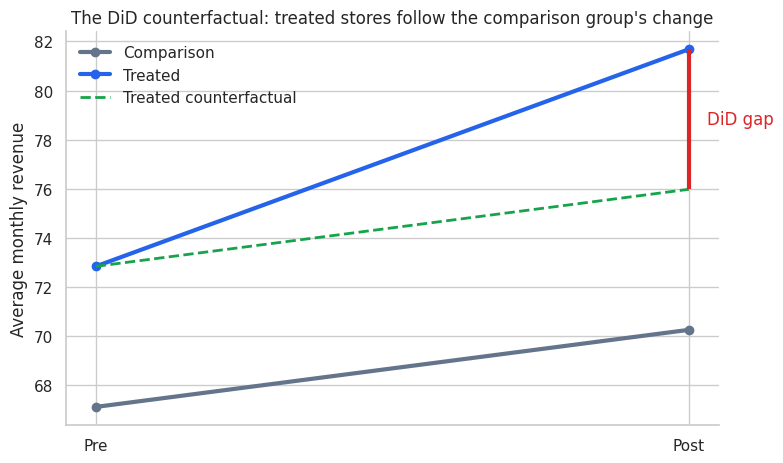

In [8]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
means_for_plot = group_means[["Pre", "Post"]].reset_index().melt(
    id_vars="treated_region", var_name="period", value_name="avg_revenue"
)
means_for_plot["period_num"] = means_for_plot["period"].map({"Pre": 0, "Post": 1})

fig, ax = plt.subplots(figsize=(8, 4.8))
for group, color in [("Comparison", "#64748b"), ("Treated", "#2563eb")]:
    tmp = means_for_plot[means_for_plot["treated_region"] == group]
    ax.plot(tmp["period_num"], tmp["avg_revenue"], marker="o", linewidth=3, color=color, label=group)

comparison_change = group_means.loc["Comparison", "Change"]
treated_pre = group_means.loc["Treated", "Pre"]
cf_treated_post = treated_pre + comparison_change
ax.plot([0, 1], [treated_pre, cf_treated_post], color="#16a34a", linestyle="--", linewidth=2, label="Treated counterfactual")
ax.vlines(1, cf_treated_post, group_means.loc["Treated", "Post"], color="#dc2626", linewidth=3)
ax.text(1.03, (cf_treated_post + group_means.loc["Treated", "Post"]) / 2, "DiD gap", va="center", color="#dc2626")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Average monthly revenue")
ax.set_title("The DiD counterfactual: treated stores follow the comparison group's change")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The dashed green line is the identifying move. It says: start at the treated group's pre-period level, then add the comparison group's pre-to-post change. That gives the treated group's counterfactual post-period outcome under no rollout.


## 5. Regression Form of 2x2 DiD

The 2x2 estimator can be written as a regression:

$$
Y_{it} = \alpha + \gamma D_i + \lambda Post_t + \tau(D_i \times Post_t) + \epsilon_{it}
$$

The interaction coefficient $\tau$ is the DiD estimate. The main effect for $D_i$ captures stable treated-comparison level differences. The main effect for $Post_t$ captures common time movement. The interaction captures the extra post-period change for treated units.


In [9]:
# Assemble the Regression Form of 2x2 DiD summary table used for interpretation.
collapsed = (
    df.assign(period=lambda x: np.where(x["post"].eq(1), "Post", "Pre"))
    .groupby(["store_id", "treated_region", "post"], observed=True)
    .agg(revenue=("revenue", "mean"), true_treatment_effect=("true_treatment_effect", "mean"))
    .reset_index()
)

basic_model = smf.ols("revenue ~ treated_region * post", data=collapsed).fit()
basic_row = extract_parameter(basic_model, "treated_region:post").to_frame("2x2 regression").T
basic_row["manual_DiD"] = manual_did
basic_row["true_ATT"] = true_att
smart_display(basic_row)


,estimate,std_error,ci_low,ci_high,p_value,manual_DiD,true_ATT
2x2 regression,5.701,1.026,3.685,7.716,0.000,5.701,6.000


The interaction coefficient equals the manual DiD estimate. Regression is not adding magic here; it is giving us a convenient way to add fixed effects, covariates, clustered standard errors, and later event-study leads and lags.


## 6. Panel DiD with Unit and Time Fixed Effects

Most industry DiD applications have many units and many time periods. With monthly store data, the usual fixed-effects specification is:

$$
Y_{it} = \alpha_i + \lambda_t + \tau(D_i \times Post_t) + \epsilon_{it}
$$

where:

- $\alpha_i$ is a unit fixed effect. It absorbs stable store differences.
- $\lambda_t$ is a time fixed effect. It absorbs calendar shocks common to all stores.
- $D_i \times Post_t$ marks treated stores after rollout.

In a simple two-group, one-adoption-date design with homogeneous effects, this fixed-effects coefficient is the same DiD idea applied to the full panel.


In [10]:
# Fit the statistical model and collect estimates used in the following interpretation.
fe_formula = "revenue ~ did + C(store_id) + C(month)"
fe_model_iid = smf.ols(fe_formula, data=df).fit()
fe_model_hc1 = smf.ols(fe_formula, data=df).fit(cov_type="HC1")
fe_model_cluster = smf.ols(fe_formula, data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["store_id"]},
)

model_table = pd.DataFrame(
    {
        "2x2 collapsed OLS": extract_parameter(basic_model, "treated_region:post"),
        "Panel FE iid SE": extract_parameter(fe_model_iid, "did"),
        "Panel FE robust SE": extract_parameter(fe_model_hc1, "did"),
        "Panel FE clustered by store": extract_parameter(fe_model_cluster, "did"),
    }
).T
model_table["true_ATT"] = true_att
smart_display(model_table)


,estimate,std_error,ci_low,ci_high,p_value,true_ATT
2x2 collapsed OLS,5.701,1.026,3.685,7.716,0.000,6.000
Panel FE iid SE,5.701,0.186,5.337,6.064,0.000,6.000
Panel FE robust SE,5.701,0.185,5.339,6.063,0.000,6.000
Panel FE clustered by store,5.701,0.287,5.139,6.262,0.000,6.000


In Panel DiD with Unit and Time Fixed Effects, the model output is also evidence about the trend assumption. Pre-period behavior is what makes the untreated counterfactual believable.

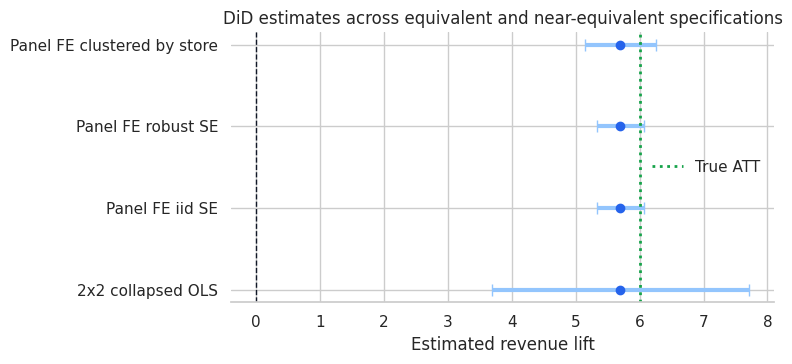

In [11]:
plot_coefficient_table(
    model_table,
    title="DiD estimates across equivalent and near-equivalent specifications",
    reference=true_att,
    xlabel="Estimated revenue lift",
);


The point estimates are very similar because the data-generating process is built to satisfy the basic DiD assumptions. The standard errors differ because the full panel contains repeated observations for the same stores. Monthly revenue is serially correlated within store, so treating all rows as independent can overstate precision. Bertrand, Duflo, and Mullainathan (2004) show that DiD studies with many periods and serially correlated outcomes can produce misleading standard errors when this dependence is ignored.

A good default for panel DiD is to cluster standard errors at the level where treatment varies. Here treatment varies at the store-region assignment level and is repeatedly observed within store, so store clustering is a natural starting point for this simulated example. In real applications, if treatment is assigned at a higher level such as region, state, market, school district, or warehouse group, clustering usually needs to respect that higher assignment level.


## 7. What Parallel Trends Means Operationally

Parallel trends concerns untreated slopes rather than equal baseline outcomes. Treated stores can be larger, more urban, or more mature. DiD can handle stable level differences.

In potential-outcome language:

$$
E[Y_{it}(0) - Y_{i,t-1}(0) \mid D_i = 1]
=
E[Y_{it}(0) - Y_{i,t-1}(0) \mid D_i = 0]
$$

for the relevant post-rollout counterfactual period. We cannot observe treated units' post-rollout untreated outcomes, so we look for supporting evidence:

- Similar pre-treatment trends.
- No known group-specific shocks at the rollout date.
- Stable composition of units across periods.
- Placebo tests using fake treatment dates before the real rollout.
- Robustness to comparison-group definitions.
- Domain knowledge that treated and comparison groups were exposed to the same market environment.

Ryan (2018) notes that visual and statistical evidence are commonly combined when assessing parallel trends, but neither can prove the assumption. Pre-trend checks are diagnostic evidence, not a theorem.


In [12]:
pre_df = df[df["month"] < 0].copy()
pretrend_model = smf.ols("revenue ~ treated_region * month", data=pre_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": pre_df["store_id"]},
)
pretrend_row = extract_parameter(pretrend_model, "treated_region:month").to_frame("pre_period_treated_slope_difference").T
smart_display(pretrend_row)


,estimate,std_error,ci_low,ci_high,p_value
pre_period_treated_slope_difference,0.055,0.090,-0.121,0.231,0.539


The pre-period interaction between treated status and month estimates whether treated stores had a different pre-rollout slope from comparison stores. In this simulated valid design, that estimate is close to zero.

This is useful, but be careful. A statistically insignificant pre-trend leaves parallel trends as an assumption. It may simply mean the pre-period is short or noisy. A statistically significant pre-trend is more damaging because it directly shows that the simple parallel-trends story is not describing the pre-period well.


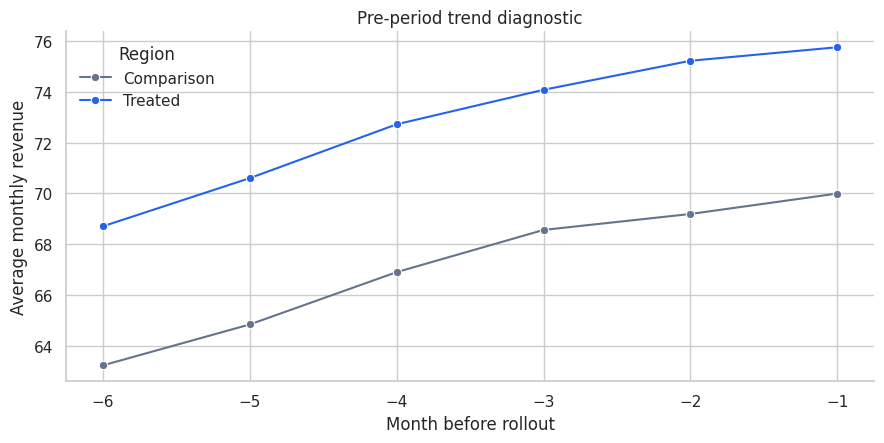

In [13]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
pre_trend = (
    pre_df.groupby(["treated_region", "month"], observed=True)["revenue"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.6))
sns.lineplot(
    data=pre_trend,
    x="month",
    y="revenue",
    hue="treated_region",
    marker="o",
    palette={0: "#64748b", 1: "#2563eb"},
    ax=ax,
)
ax.set_title("Pre-period trend diagnostic")
ax.set_xlabel("Month before rollout")
ax.set_ylabel("Average monthly revenue")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Comparison", "Treated"], title="Region", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


For professional use, the plot matters as much as the p-value. A business stakeholder can see whether the treated and comparison groups were moving together before rollout. The analyst should explain both the visual pattern and the statistical check.


## 8. Placebo Timing Test

A placebo timing test pretends the intervention happened before it actually happened. If DiD estimates a large effect before the rollout, the design is probably detecting differential trends rather than the intervention.

Here we use only pre-rollout months and pretend the policy started three months early.


In [14]:
# Assemble the Placebo Timing Test summary table used for interpretation.
placebo_df = df[df["month"] < 0].copy()
placebo_df["fake_post"] = (placebo_df["month"] >= -3).astype(int)
placebo_df["fake_did"] = placebo_df["treated_region"] * placebo_df["fake_post"]

placebo_model = smf.ols("revenue ~ fake_did + C(store_id) + C(month)", data=placebo_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": placebo_df["store_id"]},
)
placebo_table = extract_parameter(placebo_model, "fake_did").to_frame("fake_rollout_at_month_minus_3").T
smart_display(placebo_table)


,estimate,std_error,ci_low,ci_high,p_value
fake_rollout_at_month_minus_3,0.084,0.317,-0.537,0.706,0.790


The placebo estimate is near zero in the valid simulation. That is what we want: before the support program existed, treated stores did not exhibit a fake treatment effect.

A placebo test is most persuasive when the fake treatment date is chosen before seeing the result, or when several pre-period placebo windows tell a consistent story. If many placebo tests are tried and only the favorable one is reported, the diagnostic becomes theater rather than evidence.


## 9. Adding Covariates: Precision Versus Identification

DiD is often estimated with additional covariates:

$$
Y_{it} = \alpha_i + \lambda_t + \tau(D_i \times Post_t) + X_{it}'\beta + \epsilon_{it}
$$

Covariates can improve precision and can help when parallel trends is more plausible conditional on measured variables. Abadie (2005) formalizes semiparametric DiD approaches that combine DiD with adjustment for observed covariates.

But covariates should be chosen carefully. Good candidates are pre-treatment characteristics or time-varying controls that are not caused by the treatment. Bad candidates include post-treatment mediators, such as the number of outreach calls created by the support program, because controlling for them can remove part of the treatment effect.


In [15]:
# Assemble the Adding Covariates: Precision Versus Identification summary table used for interpretation.
fe_model_with_demand = smf.ols(
    "revenue ~ did + demand_index + C(store_id) + C(month)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["store_id"]})

covariate_table = pd.DataFrame(
    {
        "FE without demand covariate": extract_parameter(fe_model_cluster, "did"),
        "FE with local demand covariate": extract_parameter(fe_model_with_demand, "did"),
    }
).T
covariate_table["true_ATT"] = true_att
smart_display(covariate_table)


,estimate,std_error,ci_low,ci_high,p_value,true_ATT
FE without demand covariate,5.701,0.287,5.139,6.262,0.000,6.000
FE with local demand covariate,5.963,0.265,5.443,6.483,0.000,6.000


The estimate stays close to the same treatment effect. The standard error can move because local demand explains some within-store revenue variation. In this simulation, the demand index is not caused by the rollout, so it is safe to include. In a real project, every covariate should be passed through the causal diagram: is it a pre-treatment predictor, an exogenous time-varying control, a mediator, or a collider?


## 10. Failure Mode 1: Treated Group Gets a Post-Rollout Shock

The most direct DiD failure is a group-specific post-period shock. Suppose the treated region experiences a competitor launch, supply shortage, executive discounting freeze, data outage, or staffing disruption at the same time as the support program. A fixed-effects DiD model cannot separate the support program from that simultaneous treated-region shock.

This violates the common-shocks logic: calendar shocks are no longer common across treated and comparison groups.


In [16]:
# Fit the Failure Mode 1: Treated Group Gets a Post-Rollout Shock model and collect the estimate needed below.
df_shock = simulate_retail_did(treated_post_shock=-4.0)
shock_true_att = df_shock.loc[df_shock["did"] == 1, "true_treatment_effect"].mean()
shock_model = smf.ols("revenue ~ did + C(store_id) + C(month)", data=df_shock).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_shock["store_id"]},
)
shock_estimate = extract_parameter(shock_model, "did").to_frame("DiD with unmodeled treated-region shock").T
shock_estimate["true_program_ATT"] = shock_true_att
shock_estimate["shock_bias"] = shock_estimate["estimate"] - shock_true_att
smart_display(shock_estimate)


,estimate,std_error,ci_low,ci_high,p_value,true_program_ATT,shock_bias
DiD with unmodeled treated-region shock,1.701,0.287,1.139,2.262,0.000,6.000,-4.299


In Failure Mode 1: Treated Group Gets a Post-Rollout Shock, the model output is also evidence about the trend assumption. If the pre-period comparison is weak, the treatment effect should be read cautiously.

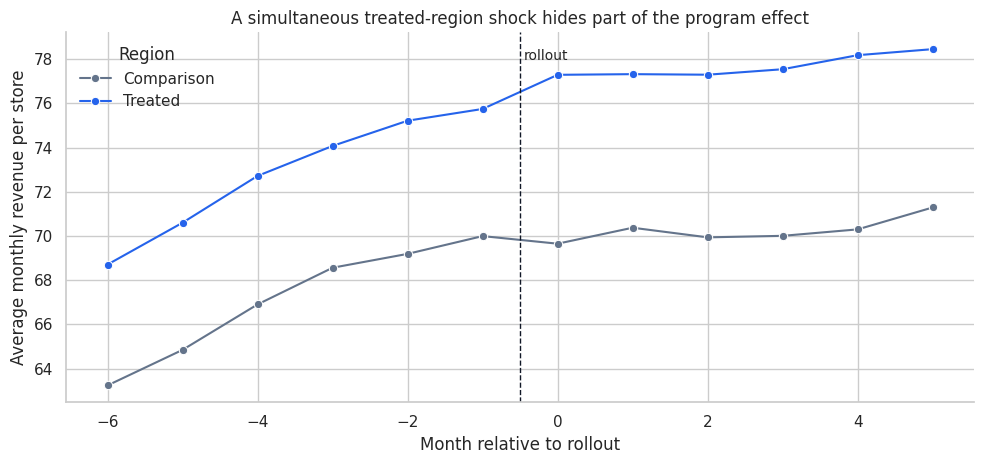

In [17]:
plot_group_trends(df_shock, title="A simultaneous treated-region shock hides part of the program effect");


The support program still has the same true causal effect, but the treated region receives a negative non-program shock at the rollout date. DiD estimates the combined effect of the program and the shock. The result is biased downward.

This is why a DiD readout should always include a rollout-history section: what else changed for treated units around the same time? In industry, that audit often matters more than another regression specification.


## 11. Failure Mode 2: Non-Parallel Pre-Trends

Now suppose treated stores were already growing faster before rollout. The basic DiD estimator will tend to attribute part of that existing growth difference to the treatment.


In [18]:
# Fit the statistical model and collect estimates used in the following interpretation.
df_nonparallel = simulate_retail_did(differential_trend=0.35)
nonparallel_true_att = df_nonparallel.loc[df_nonparallel["did"] == 1, "true_treatment_effect"].mean()
nonparallel_model = smf.ols("revenue ~ did + C(store_id) + C(month)", data=df_nonparallel).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_nonparallel["store_id"]},
)

nonparallel_pre = df_nonparallel[df_nonparallel["month"] < 0].copy()
nonparallel_pretrend = smf.ols("revenue ~ treated_region * month", data=nonparallel_pre).fit(
    cov_type="cluster",
    cov_kwds={"groups": nonparallel_pre["store_id"]},
)

nonparallel_table = pd.DataFrame(
    {
        "DiD estimate under nonparallel trends": extract_parameter(nonparallel_model, "did"),
        "Pre-period treated slope difference": extract_parameter(nonparallel_pretrend, "treated_region:month"),
    }
).T
nonparallel_table.loc["DiD estimate under nonparallel trends", "true_ATT"] = nonparallel_true_att
smart_display(nonparallel_table)


,estimate,std_error,ci_low,ci_high,p_value,true_ATT
DiD estimate under nonparallel trends,7.801,0.287,7.239,8.362,0.000,6.000
Pre-period treated slope difference,0.405,0.090,0.229,0.581,0.000,NaN


In Failure Mode 2: Non-Parallel Pre-Trends, the model output is also evidence about the trend assumption. The design claim lives in the pre-period comparison as much as in the coefficient.

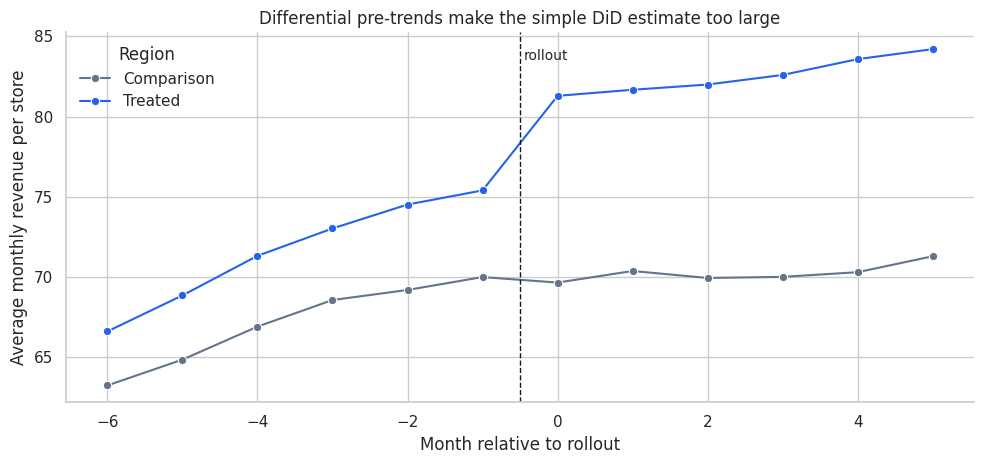

In [19]:
plot_group_trends(df_nonparallel, title="Differential pre-trends make the simple DiD estimate too large");


The pre-period slope diagnostic is no longer close to zero. The treated group was already pulling away before the rollout. In a real analysis, this would trigger a redesign, not just a footnote.

Possible responses include:

- Find a more comparable control group.
- Restrict to units with similar pre-period histories.
- Match or weight on pre-treatment outcomes and covariates.
- Model group-specific trends only when the domain story supports that extrapolation.
- Move to synthetic control if there is one treated aggregate unit and many candidate controls.
- Reframe the result as descriptive if the counterfactual trend cannot be defended.

The next notebooks will go deeper into event studies, staggered adoption, and synthetic control. For now, the key point is that DiD is a design, not just a regression coefficient.


## 12. A Compact Design Checklist

Before presenting a DiD estimate, answer these questions:

1. **Intervention timing:** Is there a clear rollout date? Did units know about it in advance?
2. **Treatment assignment:** Why were these units treated? Was the timing related to expected outcome changes?
3. **Comparison group:** Why should the comparison group represent the treated group's untreated trend?
4. **Pre-trends:** Do treated and comparison units move similarly before rollout?
5. **Concurrent shocks:** What else changed at the same time for treated units?
6. **Composition:** Are the same types of units observed before and after?
7. **Spillovers:** Could comparison units be affected by the treated group's rollout?
8. **Inference:** At what level was treatment assigned, and are standard errors clustered accordingly?
9. **Outcome timing:** Should the effect be immediate, delayed, or cumulative?
10. **Decision link:** What action will the estimate inform?


## 13. Industry Readout Template

A useful DiD readout should not bury the design behind model output. A good structure is:

- **Decision:** What business decision depends on the estimate?
- **Intervention:** What changed, where, and when?
- **Estimand:** ATT for treated units after rollout, with outcome and time window specified.
- **Comparison group:** Why these units are credible controls.
- **Identification argument:** Why parallel trends and common shocks are plausible.
- **Diagnostics:** Pre-trend plot, placebo timing test, and concurrent-shock audit.
- **Estimate:** DiD point estimate, confidence interval, and practical scale.
- **Risks:** Known threats such as spillovers, composition changes, or simultaneous programs.
- **Recommendation:** Ship, expand, pause, redesign, or run a randomized follow-up.


In [20]:
# Build the summary table used to connect the calculation back to the design question.
readout = pd.DataFrame(
    {
        "Item": [
            "Intervention",
            "Estimand",
            "Primary estimate",
            "Uncertainty",
            "Design evidence",
            "Main threat",
            "Decision implication",
        ],
        "Example entry": [
            "Proactive support program launched in treated region at month 0",
            "ATT for treated stores during the six post-rollout months",
            f"{fe_model_cluster.params['did']:.2f} revenue units per store-month",
            f"95% CI [{fe_model_cluster.conf_int().loc['did', 0]:.2f}, {fe_model_cluster.conf_int().loc['did', 1]:.2f}] with store-clustered SEs",
            "Parallel pre-period trends and near-zero fake rollout estimate",
            "Any treated-region operational shock at month 0 would be confounded with rollout",
            "Scale if operational audit confirms no simultaneous treated-region shock",
        ],
    }
)
smart_display(readout)


,Item,Example entry
0,Intervention,Proactive support program launched in treated region at month 0
1,Estimand,ATT for treated stores during the six post-rollout months
2,Primary estimate,5.70 revenue units per store-month
3,Uncertainty,"95% CI [5.14, 6.26] with store-clustered SEs"
4,Design evidence,Parallel pre-period trends and near-zero fake rollout estimate
5,Main threat,Any treated-region operational shock at month 0 would be confounded with rollout
6,Decision implication,Scale if operational audit confirms no simultaneous treated-region shock


## Key Takeaways

- DiD estimates the extra change in treated units relative to comparison units.
- The identifying assumption is about untreated trends, not baseline levels.
- The basic 2x2 estimator and the interaction-regression estimator are the same arithmetic.
- Unit fixed effects remove stable unit differences; time fixed effects remove shocks common to all units.
- Repeated panel observations usually require clustered standard errors at the treatment-assignment level.
- Pre-trend plots and placebo timing tests are diagnostics, not proof.
- A simultaneous treated-group shock at the rollout date is a direct threat to DiD.
- In applied work, the design narrative is as important as the regression table.


## 14. Real-Data Companion: Grunfeld Panel as a DiD Design Rehearsal

Difference-in-differences needs treated and comparison groups observed before and after an intervention. Many real datasets have the panel structure but not a credible intervention. The Grunfeld investment panel is useful for practicing the diagnostics without pretending that we have a real policy shock.

Below, we create a deliberately artificial split between firms with high and low pre-period market value, then define a post period. This is not a causal estimate. It is a rehearsal for the mechanics: group trends, pre-period differences, fixed effects, and the danger of reading a convenient panel as if it were a designed quasi-experiment.

Data source: [statsmodels Grunfeld dataset](https://www.statsmodels.org/stable/datasets/generated/grunfeld.html).

**How to read this real-data section.** Use the data to stress-test the diagnostics. Real covariates and real measurement make the exercise useful, but identification still comes from the design rather than the method name.


**Real-data dataset note.** The Grunfeld panel contains firms observed over time, with investment and firm-value measures. It has the panel shape needed for DiD, but it does not provide a credible policy shock in this notebook. We create an artificial split and boundary only to rehearse the mechanics of group trends, fixed effects, and pre-period diagnostics. The exercise is intentionally not causal. It teaches a crucial design lesson: before-after panel structure is only a container; identification comes from a real intervention story, timing, exposure definition, and comparison-group argument.

,quantity,estimate,std_error_clustered_by_firm,warning
0,Artificial DiD interaction,90.028000,54.250000,Design rehearsal only. No real intervention is being claimed.


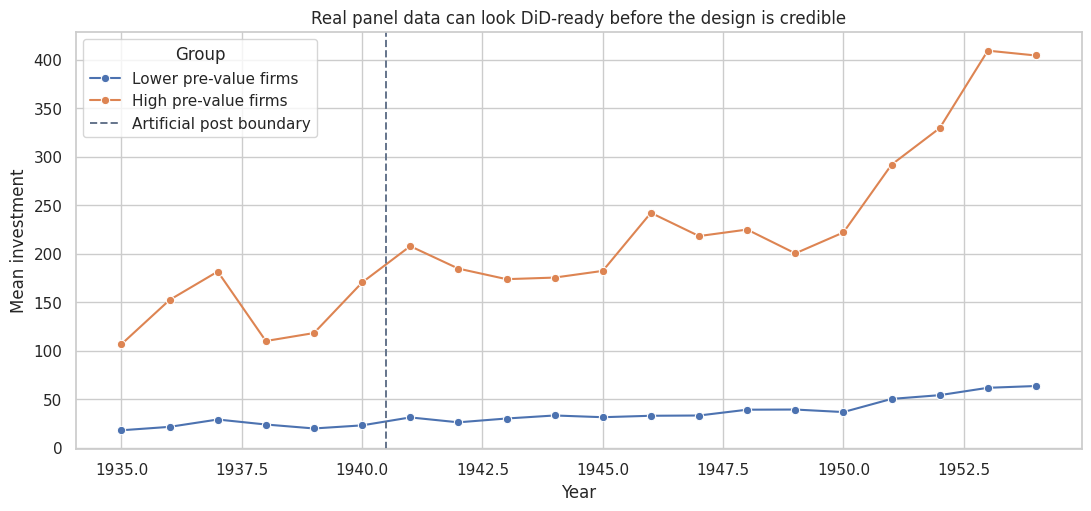

In [21]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_statsmodels_grunfeld, optional_data_note

RUN_REAL_DATA_COMPANION = True
GRUNFELD_SOURCE = "https://www.statsmodels.org/stable/datasets/generated/grunfeld.html"

if RUN_REAL_DATA_COMPANION:
    grunfeld = load_statsmodels_grunfeld().copy()
    grunfeld["year"] = grunfeld["year"].astype(int)
    pre_period = grunfeld["year"] <= 1940
    firm_pre_value = grunfeld.loc[pre_period].groupby("firm")["value"].mean()
    high_value_firms = firm_pre_value[firm_pre_value >= firm_pre_value.median()].index
    grunfeld["high_pre_value_firm"] = grunfeld["firm"].isin(high_value_firms).astype(int)
    grunfeld["post_1940"] = (grunfeld["year"] > 1940).astype(int)

    did_like = smf.ols(
        "invest ~ high_pre_value_firm * post_1940 + C(firm) + C(year)",
        data=grunfeld,
    ).fit(cov_type="cluster", cov_kwds={"groups": grunfeld["firm"]})

    did_like_table = pd.DataFrame(
        [
            {
                "quantity": "Artificial DiD interaction",
                "estimate": did_like.params["high_pre_value_firm:post_1940"],
                "std_error_clustered_by_firm": did_like.bse["high_pre_value_firm:post_1940"],
                "warning": "Design rehearsal only. No real intervention is being claimed.",
            }
        ]
    )
    smart_display(did_like_table.round(3))

    trend_frame = (
        grunfeld.groupby(["year", "high_pre_value_firm"])["invest"]
        .mean()
        .reset_index()
        .assign(group=lambda d: np.where(d["high_pre_value_firm"] == 1, "High pre-value firms", "Lower pre-value firms"))
    )

    fig, ax = plt.subplots(figsize=(10.8, 5.0), constrained_layout=True)
    sns.lineplot(data=trend_frame, x="year", y="invest", hue="group", marker="o", ax=ax)
    ax.axvline(1940.5, color="#64748b", linestyle="--", linewidth=1.4, label="Artificial post boundary")
    ax.set_title("Real panel data can look DiD-ready before the design is credible")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean investment")
    ax.legend(title="Group")
    plt.show()
else:
    optional_data_note("Grunfeld firm investment panel", GRUNFELD_SOURCE, "RUN_REAL_DATA_COMPANION")

The companion is intentionally uncomfortable. The code can fit a DiD-style model, but the design is not credible unless we can explain what changed, why the timing is meaningful, and why the comparison group represents the counterfactual trend.

This is a useful industry habit. A dataset having before/after observations and multiple groups is only the beginning. The causal design comes from the intervention story, timing, exposure definition, and diagnostics.

## References

Abadie, A. (2005). Semiparametric difference-in-differences estimators. *The Review of Economic Studies, 72*(1), 1-19. https://doi.org/10.1111/0034-6527.00321

Bertrand, M., Duflo, E., & Mullainathan, S. (2004). How much should we trust differences-in-differences estimates? *The Quarterly Journal of Economics, 119*(1), 249-275. https://doi.org/10.1162/003355304772839588

Callaway, B. (2022). Difference-in-differences for policy evaluation. *arXiv*. https://doi.org/10.48550/arXiv.2203.15646

Card, D., & Krueger, A. B. (1993). Minimum wages and employment: A case study of the fast food industry in New Jersey and Pennsylvania. *National Bureau of Economic Research*. https://doi.org/10.3386/w4509

Ryan, A. M. (2018). Now trending: Coping with non-parallel trends in difference-in-differences analysis. *Statistical Methods in Medical Research, 28*(12), 3697-3711. https://doi.org/10.1177/0962280218814570
